In [3]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="HuggingFaceTB/SmolVLM-500M-Instruct",
    local_dir="./SmolVLM-500M-Instruct",
    ignore_patterns=[
        "*.msgpack",
        "*.h5",
        "*.onnx",
        "*.tflite",
        "*.ot",
        "*.safetensors.index.json",
    ],
)

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

'C:\\Users\\rinaa\\Desktop\\itmo\\2 semester\\2.1 neural networks\\vlm\\SmolVLM-500M-Instruct'

In [ ]:
import torch
from pathlib import Path
from transformers import AutoProcessor, AutoModelForImageTextToText
import os
import json

MODEL_DIR = Path("./SmolVLM-500M-Instruct")

processor = AutoProcessor.from_pretrained(
    str(MODEL_DIR),
    local_files_only=True,
)

model = AutoModelForImageTextToText.from_pretrained(
    str(MODEL_DIR),
    torch_dtype=torch.float32,
    local_files_only=True,
    low_cpu_mem_usage=True,
)

model.eval()

print("SmolVLM загружена:", MODEL_DIR.resolve())

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

SmolVLM загружена: C:\Users\rinaa\Desktop\itmo\2 semester\2.1 neural networks\vlm\SmolVLM-500M-Instruct


In [6]:
import transformers
print(transformers.__version__)

5.9.0


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

Модель загружена: C:\Users\rinaa\Desktop\itmo\2 semester\2.1 neural networks\vlm\SmolVLM-500M-Instruct


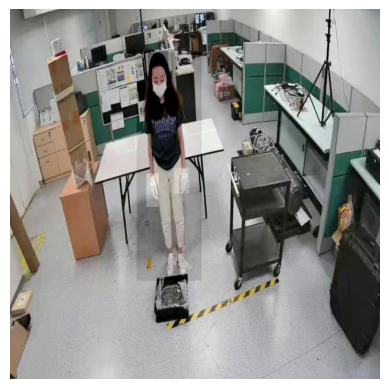

In [ ]:
import torch
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from transformers import AutoProcessor, AutoModelForImageTextToText
from PIL import Image

# --------------------
# ПУТИ
# --------------------
MODEL_DIR = Path("./SmolVLM-500M-Instruct")
TEST_IMAGE = Path("./data/-01-16-2-4-2-2-33_jpg.rf.e314997ea7789b9c5f6124c04783d3a7.jpg")
TEST_PROMPT = "Сколько людей в кадре? Опиши их очень подробно"

# --------------------
# ПРОВЕРКИ
# --------------------
if not MODEL_DIR.is_dir():
    raise FileNotFoundError(f"Модель не найдена: {MODEL_DIR.resolve()}")

if not TEST_IMAGE.is_file():
    raise FileNotFoundError(f"Картинка не найдена: {TEST_IMAGE.resolve()}")

# --------------------
# ЗАГРУЗКА МОДЕЛИ
# --------------------
processor = AutoProcessor.from_pretrained(
    str(MODEL_DIR),
    local_files_only=True,
)

model = AutoModelForImageTextToText.from_pretrained(
    str(MODEL_DIR),
    torch_dtype=torch.float32,   # если есть GPU → можно float16
    local_files_only=True,
    low_cpu_mem_usage=True,
)

model.eval()

print("Модель загружена:", MODEL_DIR.resolve())

# --------------------
# ПОКАЗ КАРТИНКИ
# --------------------
image = cv2.imread(str(TEST_IMAGE))[:, :, ::-1]
plt.imshow(image)
plt.axis("off")
plt.show()



In [ ]:
# --------------------
# ФОРМИРОВАНИЕ ЗАПРОСА
# --------------------
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": str(TEST_IMAGE)},
            {"type": "text", "text": TEST_PROMPT},
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

image = Image.open(TEST_IMAGE).convert("RGB")

inputs = processor(
    text=text,
    images=image,
    return_tensors="pt",
)

# перенос на устройство модели
inputs = {k: v.to(model.device) for k, v in inputs.items()}

# --------------------
# ГЕНЕРАЦИЯ
# --------------------
generated_ids = model.generate(
    **inputs,
    max_new_tokens=128,
    do_sample=False,
)

# --------------------
# ДЕКОД ОТВЕТА
# --------------------
answer = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)[0]

print("\nПромпт:", TEST_PROMPT)
print("\nОтвет:", answer)


Промпт: Сколько людей в кадре? Опиши их очень подробно

Ответ: User:




Сколько людей в кадре? Опиши их очень подробно
Assistant: 1.


In [ ]:
IMAGE_DIR = "./data"

PROMPT = """
Опиши изображение кратко и информативно.
Укажи:
- главные объекты
- действия
- сцену
Ответь одним предложением.
ОПИСЫВАЙ МАКСИМАЛЬНО ПОДРОБНО, КАЖДЫЙ ЭЛЕМЕНТ, КАЖДОЕ ДЕЙСТВИЕ!!!
"""

all_items = []

files = sorted(os.listdir(IMAGE_DIR))

for file_name in files[:5]:

    if not file_name.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
        continue

    image_path = os.path.join(IMAGE_DIR, file_name)

    print(f"Processing: {file_name}")
    image = Image.open(image_path).convert("RGB")

    # --------------------
    # CHAT FORMAT
    # --------------------
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": PROMPT},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    # --------------------
    # PROCESSOR
    # --------------------
    inputs = processor(
        text=text,
        images=image,
        return_tensors="pt",
    )

    # перенос на устройство
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # --------------------
    # GENERATE
    # --------------------
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False,
    )

    # --------------------
    # DECODE
    # --------------------
    output_text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
    )[0]

    item = {
        "image": image_path,
        "text": output_text,
    }

    all_items.append(item)

    print(output_text)

# --------------------
# SAVE
# --------------------
with open("dataset.jsonl", "w", encoding="utf-8") as f:
    for item in all_items:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

Processing: -01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg
User:





Опиши изображение кратко и информативно.
Укажи:
- главные объекты
- действия
- сцену
Ответь одним предложением.
ОПИСЫВАЙ МАКСИМАЛЬНО ПОДРОБНО, КАЖДЫЙ ЭЛЕМЕНТ, КАЖДОЕ ДЕЙСТВИЕ!!!

Assistant: Гарантий для производства.
Processing: -01-16-2-3-2-5-15_jpg.rf.705a29a51fa44f15dbe29adcaf09d2e0.jpg
User:





Опиши изображение кратко и информативно.
Укажи:
- главные объекты
- действия
- сцену
Ответь одним предложением.
ОПИСЫВАЙ МАКСИМАЛЬНО ПОДРОБНО, КАЖДЫЙ ЭЛЕМЕНТ, КАЖДОЕ ДЕЙСТВИЕ!!!

Assistant: Гарантии, которые пришли в рамках.
Processing: -01-16-2-3-2-5-20_jpg.rf.ff89baa4ddffc68390a744645a32236d.jpg
User:





Опиши изображение кратко и информативно.
Укажи:
- главные объекты
- действия
- сцену
Ответь одним предложением.
ОПИСЫВАЙ МАКСИМАЛЬНО ПОДРОБНО, КАЖДЫЙ ЭЛЕМЕНТ, КАЖДОЕ ДЕЙСТВИЕ!!!

Assistant: Одна из страниц, которые предлагает производить предложение. Они производят предложение на красном плане. Они про